In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [8]:
len(words)

32033

In [9]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
# print(stoi)
itos = {v: k for k, v in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [10]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size

    for ch in w + '.':
        ix = stoi[ch]
        # print(''.join(itos[i] for i in context),' --> ', ch)
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)

In [11]:
X.shape, X.dtype, Y.shape, Y. dtype 

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [12]:
C = torch.randn((27, 2))

In [13]:
C[X].shape

torch.Size([228146, 3, 2])

In [14]:
# example on how pytorch indexing works. C[X]
eg = torch.tensor([[0, 0, 1],[0, 1, 1]])
print('eg.shape:  ', eg.shape)
print('C[eg].shape', C[eg].shape)
C[eg]

eg.shape:   torch.Size([2, 3])
C[eg].shape torch.Size([2, 3, 2])


tensor([[[ 0.7007, -0.4159],
         [ 0.7007, -0.4159],
         [-0.7498, -1.7487]],

        [[ 0.7007, -0.4159],
         [-0.7498, -1.7487],
         [-0.7498, -1.7487]]])

In [15]:
C[X][13, 2]

tensor([-0.7498, -1.7487])

In [16]:
X[13, 2]

tensor(1)

In [17]:
# C[X][13, 2] = C[X[13, 2]]
C[1]

tensor([-0.7498, -1.7487])

In [18]:
# embedd all of the integers in X
emb =  C[X]
emb.shape

torch.Size([228146, 3, 2])

In [19]:
# implementing the hidden layer

# no. of inputs to the hidden layer is 6 with our current settings. Why?
# because we have 2 dimensional embeddings of 3 units of look-up tables.(3 previous chars(context_length) to predict the 4th char)
W1 = torch.randn((6, 100))
b1 = torch.rand(100)

# emb @ W1 + b1  # work won't 

In [20]:
# We need to transform emb to (32, 6) from (32, 3, 2) to perform dot product with W1 (6, 100 )

# emb[:, 0, :]
emb[:, 0, :].shape
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1 )

torch.Size([228146, 2])

In [236]:
a = torch.tensor([[[1, 2], [3, 4], [5, 6]],[[7, 8], [9, 10], [11, 12]], [[13, 14], [15, 16], [17, 18]]])
print(a)
print(a.shape)
# print(torch.unbind(a, 1))
print(torch.cat(torch.unbind(a, 1), 1))
print(torch.cat(torch.unbind(a, 1), 1).shape)

# torch.cat(torch.unbind(emb, 1), 1) == torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1 )

tensor([[[ 1,  2],
         [ 3,  4],
         [ 5,  6]],

        [[ 7,  8],
         [ 9, 10],
         [11, 12]],

        [[13, 14],
         [15, 16],
         [17, 18]]])
torch.Size([3, 3, 2])
tensor([[ 1,  2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11, 12],
        [13, 14, 15, 16, 17, 18]])
torch.Size([3, 6])


In [22]:
# this is one way to transform the input to (32, 6) tensor using torch.cat(torch.unbind(emb,1),1)
# but turns out there is a different way which is a much efficient way than this! (explained in next cell)

# torch.unbind(emb, 1)
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([228146, 6])

In [235]:
# calling .view() is extremely effiecient in pytorch. Reason for that is that in each tensor, 
# there's something called the underlying storage.

# tensor.view() works as long as the product of the dims is equal to the size of the tensor. 
a = torch.tensor([[[1, 2], [3, 4], [5, 6]],[[7, 8], [9, 10], [11, 12]], [[13, 14], [15, 16], [17, 18]]])
print(a)
print(a.shape)
a.view(3, 6)
# a.view(9, 2)
# a.view(3, 3, 2)

tensor([[[ 1,  2],
         [ 3,  4],
         [ 5,  6]],

        [[ 7,  8],
         [ 9, 10],
         [11, 12]],

        [[13, 14],
         [15, 16],
         [17, 18]]])
torch.Size([3, 3, 2])


tensor([[ 1,  2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11, 12],
        [13, 14, 15, 16, 17, 18]])

In [24]:
# the storage is just the numbers always stored as a one-dimensional vector and 
# this is how a tensor is represented in the computer memory.
# so when view() is manipulating how this 1-d sequence is interpreted as a n-dimensional tensor.
# No memory is changed, copied, moved or deleted while we call tensor.view(), 
# instead some storage attributes storage offsets, strides and shapes are amnipulated.
# For more information:  (https://blog.ezyang.com/2019/05/pytorch-internals/)

In [25]:
emb.shape

torch.Size([228146, 3, 2])

In [26]:
# emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)
# emb.view(-1, 6) # pytorch will infer the value at -1 automatically!

h = torch.tanh(emb.view(-1, 6) @ W1 + b1)  # output of the hidden layer
h

tensor([[-7.3509e-01, -9.9050e-01, -9.0825e-01,  ..., -5.6198e-01,
         -9.3152e-01,  9.5587e-01],
        [-9.0170e-01, -9.4422e-01, -9.7297e-01,  ...,  1.1426e-04,
         -9.6323e-01,  9.8995e-01],
        [-8.2962e-01, -9.9046e-01, -9.6927e-01,  ...,  6.9162e-01,
         -9.1400e-01,  9.6138e-01],
        ...,
        [ 9.6581e-01,  2.7478e-01, -7.6765e-01,  ..., -8.5801e-01,
          6.5366e-01,  5.3282e-01],
        [ 8.7068e-01, -5.7225e-01,  8.9450e-01,  ...,  9.4796e-01,
          7.3610e-01,  9.7976e-01],
        [ 5.2664e-01,  9.9566e-01,  1.9103e-01,  ...,  9.7132e-01,
          5.9445e-01, -9.8475e-01]])

In [27]:
h.shape

torch.Size([228146, 100])

In [28]:
print((emb.view(-1, 6) @ W1).shape)
print(b1.shape)
# 32, 100   (emb.view(-1, 6) @ W1).shape
# 1,  100    updated b1.shape from broadcasting

# broadcasting process, step by step.
# step 1: Align to the right when there is shape mismatch
# step 2: Create a fake dimension(1) to the left. -> (1, 100)
# step 3: Copy the (1, 100) row vector n times to match the other tensor(n=32 in this case)
# step 4: Complete element-wise addition:  (emb.view(-1, 6) @ W1) + b1

torch.Size([228146, 100])
torch.Size([100])


In [29]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [30]:
logits = h @ W2 + b2                   # log-counts

In [31]:
logits.shape

torch.Size([228146, 27])

In [32]:
counts = logits.exp()                  # exponentiate logits to get "counts"

In [33]:
prob = counts / counts.sum(dim=1, keepdims=True)
prob.shape
# prob[1].sum()

torch.Size([228146, 27])

In [34]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [41]:
# calculate loss: negative log likelihood
# loss = -nll(torch.arange(32) is just for iterating through all training data)
# and 'Y' extract the relevant prob for each training data (Y: ground truth)

loss = -prob[torch.arange(len(X)), Y].log().mean() 
loss                                           

tensor(18.0423)

In [42]:
# now made respectable!----------

In [43]:
X.shape, Y.shape       # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [44]:
g = torch.Generator().manual_seed(2147483647)  # for reproducability

C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)

W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [45]:
sum(p.nelement() for p in parameters) # no. of parameters in total

3481

In [46]:
for p in parameters:
    p.requires_grad = True

In [47]:
# How to choose the optimal learning rate?
# create a sample of 1000 within the linear space between -3 and 0.
# 10**lre gives the exponential samples in the range [0.001(10**-3), 1(10**0)]

lre = torch.linspace(-3, 0, 1000)      
lrs = 10**lre
# lrs

In [48]:
lri = []
lossi = []

for i in range(10000):
    
    # mini-batch construct
    mb_ixs = torch.randint(0, X.shape[0], (32,))
    
    # forward pass
    emb = C[X[mb_ixs]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)            # h.shape = (32, 100)
    logits = h @ W2 + b2                                 # logits.shape = (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(dim=1, keepdims=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Y[mb_ixs])            # loss of the i-th mini-batch
    print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr  * p.grad

    # track stats
    # lri.append(lre[i])
    # lossi.append(loss.item() )

# print(loss.item())

22.70534324645996
17.74266815185547
19.699783325195312
19.625064849853516
19.0628604888916
19.22218132019043
19.894493103027344
18.030378341674805
16.022266387939453
16.87506103515625
16.924989700317383
16.88218879699707
15.990108489990234
18.411224365234375
16.26991081237793
16.071712493896484
16.2894287109375
15.8147611618042
15.706625938415527
15.310174942016602
13.759334564208984
17.86507225036621
17.107101440429688
17.613067626953125
14.47507095336914
17.620758056640625
14.007096290588379
16.51362419128418
15.45523738861084
13.457056045532227
15.197575569152832
10.911776542663574
13.758696556091309
16.19011688232422
16.200746536254883
12.066211700439453
16.165769577026367
13.304036140441895
14.431550025939941
14.252820014953613
15.901254653930664
13.696094512939453
13.771859169006348
14.657855987548828
12.739470481872559
17.128963470458984
15.624370574951172
13.119450569152832
13.563802719116211
13.280309677124023
12.653210639953613
16.795063018798828
10.529546737670898
13.5955858

In [49]:
# plt.plot(lri, lossi)

In [50]:
# loss of the entire training set
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.5747, grad_fn=<NllLossBackward0>)

In [51]:
# Split dataset into train, dev and test sets.

In [52]:
# build dataset as a function with separate splits  for training(80%), dev/validation(10%) and test(10%) purposes.
def build_dataset(words):
    block_size = 3 # context length
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
    
        for ch in w + '.':
            ix = stoi[ch]
            # print(''.join(itos[i] for i in context),' --> ', ch)
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [53]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [201]:
g = torch.Generator().manual_seed(2147483647)  # for reproducability
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [202]:
sum(p.nelement() for p in parameters) # no. of parameters in total

11897

In [203]:
for p in parameters:
    p.requires_grad = True

In [204]:
lre = torch.linspace(-3, 0, 1000)      
lrs = 10**lre

In [205]:
lri = []
lossi = []
stepi = []

In [206]:
for i in range(200000):
    
    # mini-batch construct
    mb_ixs = torch.randint(0, Xtr.shape[0], (32,))
    
    # forward pass
    emb = C[Xtr[mb_ixs]]
    h = torch.tanh(emb.view(-1, 30 ) @ W1 + b1)            # h.shape = (32, 100)
    logits = h @ W2 + b2                                 # logits.shape = (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(dim=1, keepdims=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[mb_ixs])            # loss of the i-th mini-batch
    # print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr  * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

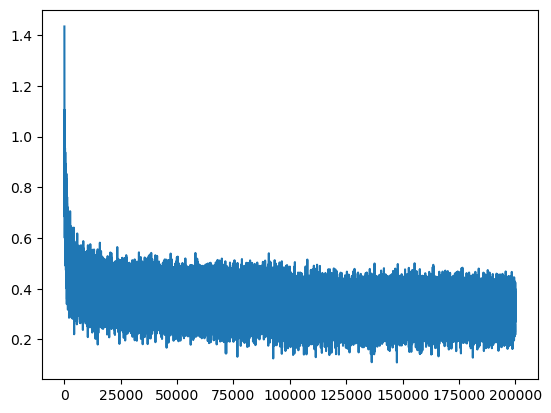

In [207]:
plt.plot(stepi, lossi)

In [208]:
 # loss of the training set
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1115, grad_fn=<NllLossBackward0>)

In [209]:
# loss of the dev set
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1567, grad_fn=<NllLossBackward0>)

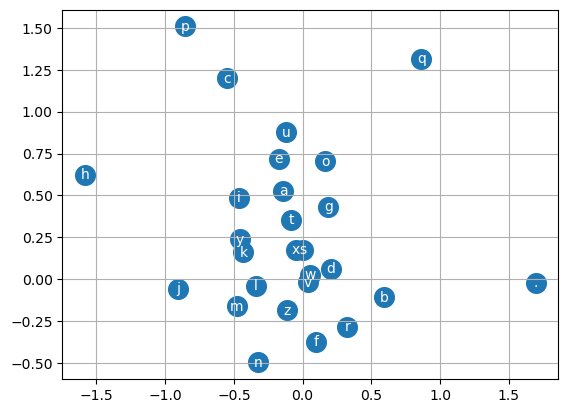

In [215]:
# Visualization works only when the embeddings(C[x]) are in 2-dimensions. 
plt.plot(figsize=(8,8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")

In [242]:
# sample from the model

g = torch.Generator().manual_seed(24147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size        # block_size = context_length; Starts with [...] to predict the first 'ix'
    # print('context: ', torch.tensor(context).shape)
    # print('context: ', torch.tensor([context]).shape)
    while(True):
        emb = C[torch.tensor([context])]
        # print('emb: ',C[torch.tensor([context])])
        # print(emb.shape)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        # print('h.shape: ',h.shape)
        logits = h @ W2 + b2
        # print('logits.shape: ',logits.shape)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if(ix == 0):
            break
    print(''.join(itos[i] for i in out))

zyond.
saurie.
carley.
hem.
ari.
khappolaiza.
armeh.
haden.
zika.
khalyn.
haiah.
roellydhsabenjamista.
mohanevatan.
fern.
meona.
bellania.
alinie.
ausey.
cambiy.
kellyn.
